In [10]:
import os
import cv2
import matplotlib.pyplot as plt
import av
from fractions import Fraction
import pandas as pd

In [2]:

frames = []
for frame in range(0, 601):
    path = os.path.join("/home/levin/dev/Simulator/data/tmp/", f"frame_{frame:06d}.png")

    img = cv2.imread(path)
    frames.append(img)

In [13]:
df = pd.read_csv("/home/levin/dev/Simulator/data/outputs/coords.txt")

In [47]:
frames_roi = []
roi_size = 100
half_size = roi_size // 2

for idx, row in df.iterrows():
    x = int(row['screen_x'])
    y = int(row['screen_y'])
    x1 = max(x - half_size, 0)
    y1 = max(y - half_size, 0)
    x2 = min(x + half_size, frames[idx].shape[1])
    y2 = min(y + half_size, frames[idx].shape[0])
    roi = frames[idx][y1:y2, x1:x2].copy()
    frames_roi.append(roi)

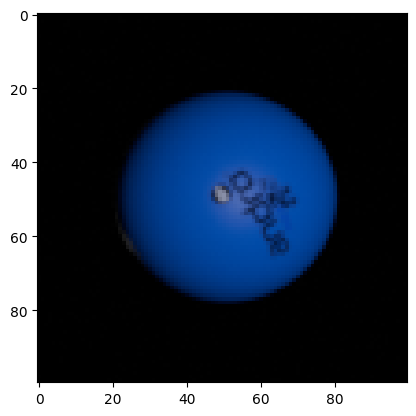

In [19]:
plt.imshow(frames_roi[500])

In [31]:
import sys
sys.path.append("../../src/utils/")
sys.path.append("../../src/utils/IEBCS/")
import eventIO
import numpy as np

In [82]:
buf = eventIO.load_hdf5("/home/levin/dev/Simulator/data/outputs/events.hdf5")
x = buf.x
y = buf.y
t = buf.ts
p = buf.p

In [84]:
print(f"Min timestamp: {t.min()}, Max timestamp: {t.max()}")
# Find the 150000 microsecond window with the most events
window_size_us = 150000
max_events = 0
best_start = 0

for start_us in range(int(t.min()), int(t.max()) - window_size_us + 1, 10000):
    end_us = start_us + window_size_us
    events_in_window = np.sum((t >= start_us) & (t < end_us))
    if events_in_window > max_events:
        max_events = events_in_window
        best_start = start_us

best_end = best_start + window_size_us
print(f"Best 150000 µs window: {best_start} - {best_end} µs")
print(f"Events in window: {max_events}")

Min timestamp: 0, Max timestamp: 159838
Best 150000 µs window: 0 - 150000 µs
Events in window: 3796144


In [86]:
# First comparison: first 9838 vs last 9838 microseconds
first_9838_mask = t < 9838
last_9838_mask = t > (t.max() - 9838)

events_first_9838 = np.sum(first_9838_mask)
events_last_9838 = np.sum(last_9838_mask)

print(f"Events in first 9838 µs: {events_first_9838}")
print(f"Events in last 9838 µs: {events_last_9838}")
print(f"Ratio (last/first): {events_last_9838 / events_first_9838:.2f}")
print()

# Second comparison: first 5000 vs last 5000 microseconds
first_5000_mask = t < 5000
last_5000_mask = t > (t.max() - 5000)

events_first_5000 = np.sum(first_5000_mask)
events_last_5000 = np.sum(last_5000_mask)

print(f"Events in first 5000 µs: {events_first_5000}")
print(f"Events in last 5000 µs: {events_last_5000}")
print(f"Ratio (last/first): {events_last_5000 / events_first_5000:.2f}")

Events in first 9838 µs: 108420
Events in last 9838 µs: 14611
Ratio (last/first): 0.13

Events in first 5000 µs: 39533
Events in last 5000 µs: 181
Ratio (last/first): 0.00


In [87]:
# Fixed binning: 601 bins, each 250 us, starting at t=0
bin_width_us = 250
n_bins = 601

t_start = 0  # start at t=0
t_end = t_start + n_bins * bin_width_us  # end after 601 bins

# exact integer edges (no float rounding)
bin_edges = t_start + np.arange(n_bins + 1, dtype=np.int64) * bin_width_us

# bin index per event
event_bins = np.searchsorted(bin_edges, t, side='right') - 1

# mark events outside the 601-frame window
event_bins[(t < bin_edges[0]) | (t > bin_edges[-1])] = -1


In [88]:
bin_idx = 0  # Replace with desired bin index
mask = event_bins == bin_idx
bin_events_x = x[mask]
bin_events_y = y[mask]
bin_events_t = t[mask]
bin_events_p = p[mask]

In [89]:
events_images = []
for bin_idx in range(n_bins):
    mask = event_bins == bin_idx
    bin_events_x = x[mask]
    bin_events_y = y[mask]
    bin_events_p = p[mask]
    event_img = np.zeros((720, 1280), dtype=np.float32)
    for ex, ey, ep in zip(bin_events_x, bin_events_y, bin_events_p):
        if ep == 1:
            event_img[ey, ex] += 1
        else:
            event_img[ey, ex] -= 1
    events_images.append(event_img)


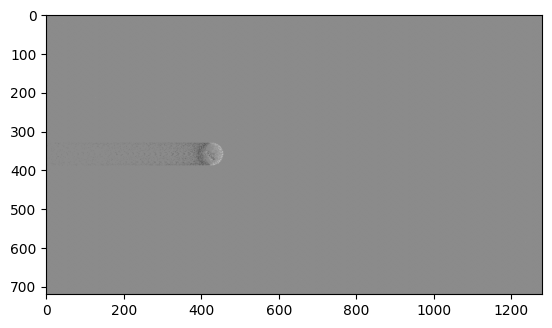

In [90]:
plt.imshow(events_images[200], cmap='gray')

In [91]:
# Normalize and convert events_images to uint8
events_images_uint8 = []
for event_img in events_images:
    # Normalize to 0-255 range
    img_min = event_img.min()
    img_max = event_img.max()
    
    if img_max - img_min > 0:
        normalized = ((event_img - img_min) / (img_max - img_min) * 255).astype(np.uint8)
    else:
        normalized = np.zeros_like(event_img, dtype=np.uint8)
    
    events_images_uint8.append(normalized)

In [92]:
events_roi = []
roi_size = 100
half_size = roi_size // 2

for idx, row in df.iterrows():
    x = int(row['screen_x'])
    y = int(row['screen_y'])
    x1 = max(x - half_size, 0)
    y1 = max(y - half_size, 0)
    x2 = min(x + half_size, events_images[idx].shape[1])
    y2 = min(y + half_size, events_images[idx].shape[0])
    roi = events_images[idx][y1:y2, x1:x2].copy()
    events_roi.append(roi)

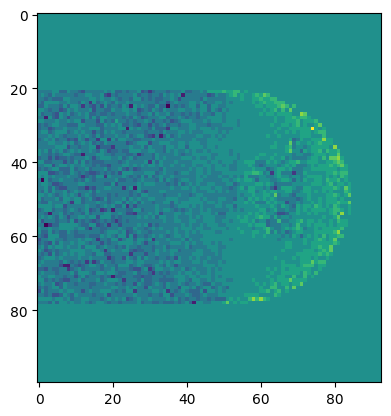

In [96]:
plt.imshow(events_roi[580])

In [100]:
# Convert events_roi to uint8 images (0-255 normalization)
events_roi_uint8 = []
for event_img in events_roi:
    img_min = event_img.min()
    img_max = event_img.max()
    if img_max - img_min > 0:
        normalized = ((event_img - img_min) / (img_max - img_min) * 255).astype(np.uint8)
    else:
        normalized = np.zeros_like(event_img, dtype=np.uint8)
    events_roi_uint8.append(normalized)

In [102]:
def write_video(frames_list, out_path, width, height, fps=30):
    container = av.open(out_path, mode='w')
    stream = container.add_stream('libx264', rate=fps)
    stream.width = width
    stream.height = height
    stream.pix_fmt = 'yuv420p'
    stream.options = {'crf': '18', "preset": "veryfast"}
    time_base = Fraction(1, fps)
    for i, img in enumerate(frames_list):
        # Ensure 3 channels and uint8
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            raise ValueError("Unexpected image shape")
        frame = av.VideoFrame.from_ndarray(img, format='rgb24')
        frame.pts = i
        frame.time_base = time_base
        for packet in stream.encode(frame):
            container.mux(packet)
    for packet in stream.encode():
        container.mux(packet)
    container.close()

write_video(events_roi_uint8, '/home/levin/dev/Master_Thesis/data/events_roi.mp4', roi_size, roi_size)
write_video(frames_roi, '/home/levin/dev/Master_Thesis/data/frames_roi.mp4', roi_size, roi_size)
write_video(events_images_uint8, '/home/levin/dev/Master_Thesis/data/events_images.mp4', 1280, 720)
write_video(frames, '/home/levin/dev/Master_Thesis/data/frames.mp4', 1280, 720)